In [6]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import display, Math, Latex
# from tqdm import tqdm
%matplotlib inline

Mean correlation: 0.7352941176470589
Standard deviation: 0.09101503735219503


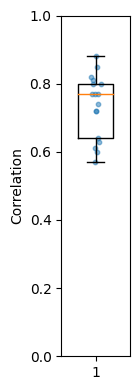

In [2]:
site_corr = [0.64, 0.77, 0.8, 0.85, 0.81, 0.61, 0.72, 0.6, 0.82, 0.77, 0.72, 0.63, 0.8, 0.57, 0.88, 0.74, 0.77]

plt.figure(figsize=(1.5, 4))
plt.boxplot(site_corr, vert=True, widths=0.5)

jitter = np.random.normal(1, 0.04, size=len(site_corr))
plt.scatter(jitter, site_corr, color='tab:blue', alpha=0.5, s=10)
plt.ylabel('Correlation')
plt.ylim(0, 1)
plt.tight_layout()
# plt.show()
# plt.savefig('site_corr_boxplot.svg', format="svg", dpi=300)

print('Mean correlation:', np.mean(site_corr))
print('Standard deviation:', np.std(site_corr))


In [11]:
import os

def save_paired_genes_to_csv(grouped, filename, chunk_size=10):
    """
    Saves clearance genes and associated risk genes to CSV files, aligning rows so that
    each clearance gene is repeated for each chunk of risk genes.

    :param grouped: Grouped pandas Series with clearance genes as the index and associated risk genes as values.
    :param clearance_filename: Name of the CSV file to save clearance genes.
    :param risk_filename: Name of the CSV file to save risk genes.
    :param chunk_size: Maximum number of risk genes per line in the output file.
    """

    # Ensure the directory exists before writing the file
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    with open(filename, 'w') as f:
        n_jobs = 0
        for clear_gene, risk_genes in grouped.items():
            n_jobs += math.ceil(len(risk_genes) / chunk_size)
            for i in range(0, len(risk_genes), chunk_size):
                f.write(clear_gene + ',' + ','.join(risk_genes[i:i + chunk_size]) + '\n')
                

    print(f'Wrote {grouped.apply(len).sum()} gene pairs in {n_jobs} jobs to {filename}')

In [3]:
# Loading information from all sites for all gene pairs is very expensive
# Here we load only gene names, seeds, and group correlations
gene_df = dd.read_csv('../results/250704/*.csv', assume_missing=True)
gene_df = gene_df.iloc[:, 0:6]

# 100M rows takes 70 min on 55GB (6 columns)
# 100M rows takes 2.5 min on A40 (6 columns)
gene_df = gene_df.compute()
gene_df_all = gene_df.copy()

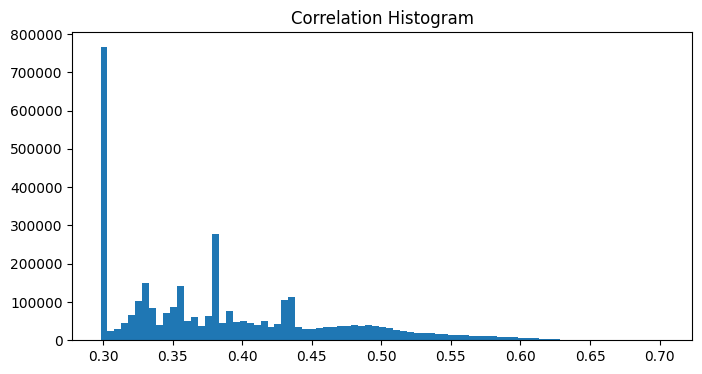

(2826015, 6)


In [4]:
gene_df = gene_df.sort_values(by='correlation', ascending=False)
gene_df = gene_df.drop_duplicates(subset=['clearance gene', 'risk gene'], keep='first')

plt.figure(figsize=(8, 4))
plt.hist(gene_df['correlation'], bins=np.arange(gene_df['correlation'].min(), gene_df['correlation'].max(), 0.005))
plt.title('Correlation Histogram')
plt.show()

# print(gene_df[gene_df['correlation'] > gene_df['correlation'].min()].shape)
print(gene_df[gene_df['correlation'] > 0.3].shape)

(715809, 6)


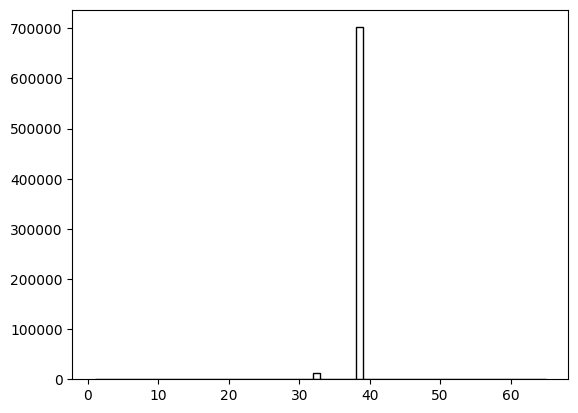

Wrote 12011 gene pairs in 250 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_32.csv
Wrote 702131 gene pairs in 3363 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_38.csv
Wrote 38 gene pairs in 11 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_53.csv
Wrote 418 gene pairs in 61 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_39.csv
Wrote 251 gene pairs in 56 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_40.csv
Wrote 45 gene pairs in 14 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_49.csv
Wrote 77 gene pairs in 20 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_33.csv
Wrote 26 gene pairs in 11 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_9.csv
Wrote 86 gene pairs in 30 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_24.csv
Wrote 95 gene pairs in 22 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_31.csv
Wrote 30 gene pairs in 14 jobs to ../data/gene_labels/250909_pairs/GO_lt_r03_6.csv
Wrote 13 gene pairs in 8 jobs to ../data/gene_labels/250909_pairs/

In [12]:
# save significant gene pairs for rerunning on null models
filtered_df = gene_df[gene_df['correlation'] < 0.3]
print(filtered_df.shape)
plt.hist(filtered_df['seed'], bins=range(1,66), edgecolor='black', fill=False)
plt.show()

for seed in filtered_df['seed'].unique():
    grouped = filtered_df[filtered_df['seed'] == seed].groupby('clearance gene')['risk gene'].apply(list)
    save_paired_genes_to_csv(grouped, f'../data/gene_labels/250909_pairs/GO_lt_r03_{int(seed)}.csv', chunk_size=220)

In [3]:
print("Number of clearance genes: %d" % len(set(gene_df['clearance gene'])))
print("Number of risk genes: %d" % len(set(gene_df['risk gene'])))
# display(gene_df.sort_values(by='correlation', ascending=False).head())

Number of clearance genes: 344
Number of risk genes: 10297


<IPython.core.display.Math object>

<IPython.core.display.Math object>

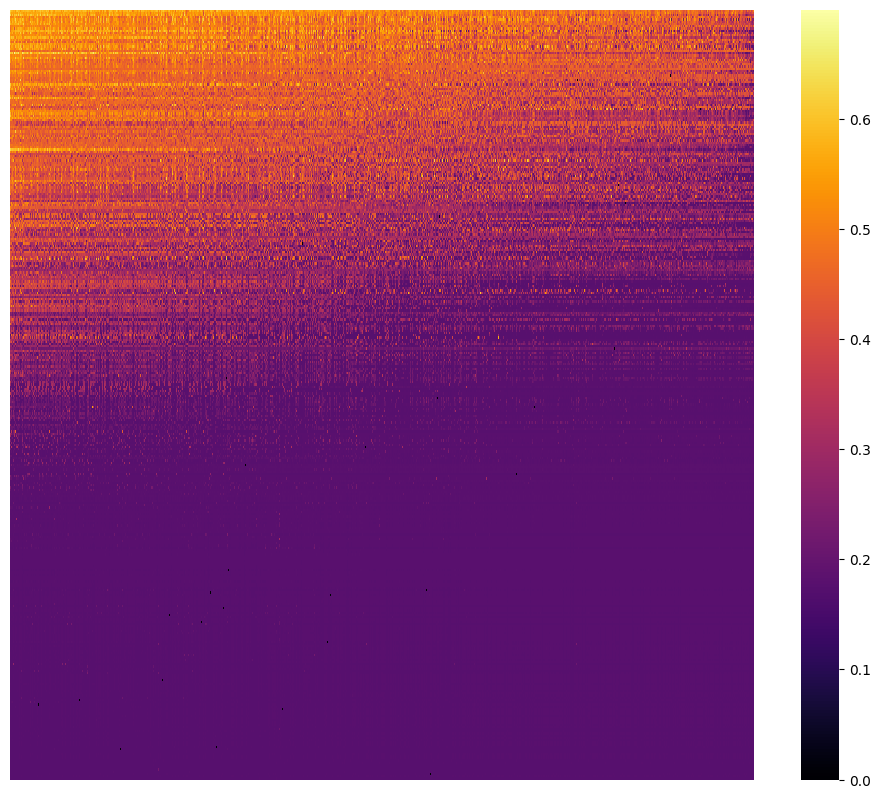

Clearance gene variance: 0.0100,  Risk gene variance: 0.0004 ratio: 25.0621
Maximum correlation: 0.700,  Mean correlation: 0.26,  S.D: 0.11
Number of gene pairs with correlation > 0.5: 129014


In [4]:
import seaborn as sns

a_hip = gene_df[gene_df['seed'] == 52.0]
for my_df in [a_hip]:
    display(Math(r'\text{Schaefer 100 + Tian S2}'))
    display(Math(r'Clearance\, rate = e^{-\frac{1}{\sqrt{2}}\beta dt},\enspace \rho \propto \sum_{n=1}^j w_{ij}'))

    # pivot table to risk x clear corr
    corr_matrix = my_df.pivot_table(index = 'clearance gene', columns = 'risk gene', values = 'correlation').fillna(0)
    corr_matrix = corr_matrix.reindex(corr_matrix.mean(axis=1).sort_values(ascending=False).index, axis=0)
    corr_matrix = corr_matrix.reindex(corr_matrix.mean(axis=0).sort_values(ascending=False).index, axis=1)

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, vmin=0, cmap='inferno', xticklabels=False, yticklabels=False)
    plt.ylabel('')
    plt.xlabel('')
    plt.show()

    row_mean = corr_matrix.mean(axis=1)
    col_mean = corr_matrix.mean(axis=0)
    # print("%s clearance genes" % gene_set)
    # print("PCA")
    print("Clearance gene variance: %.4f, " % np.var(row_mean), "Risk gene variance: %.4f" % np.var(col_mean), "ratio: %.4f" % (np.var(row_mean)/np.var(col_mean)))
    print("Maximum correlation: %.3f, " % my_df['correlation'].max(), "Mean correlation: %.2f, " % my_df['correlation'].mean(), "S.D: %.2f" %my_df['correlation'].std())
    print("Number of gene pairs with correlation > 0.5: %d" % len(my_df[my_df['correlation'] > 0.5]))


In [16]:
# Identify pairs with a correlation above threshold and load for mean deviation calculation
# <1 min A40 for 35000 pairs
import glob

thresholded = gene_df[gene_df['correlation'] > 0.6]
thresholded = thresholded.sort_values(by=['correlation'], ascending=False)
thresholded = thresholded.drop_duplicates(subset=['clearance gene', 'risk gene'], keep='first')
print("Number of gene pairs with correlation > 0.6: %d" % len(thresholded))
print("Number of clearance genes: %d" % len(set(thresholded['clearance gene'])))
print("Number of risk genes: %d" % len(set(thresholded['risk gene'])))

selected = thresholded[['clearance gene', 'seed', 'risk gene']].drop_duplicates()

# Get all unique (clearance gene, seed) pairs
unique_files = selected[['clearance gene', 'seed']].drop_duplicates()
file_paths = []
for _, row in unique_files.iterrows():
    file_path = f"../results/250704/*{row['clearance gene']}_{int(row['seed'])}.csv"
    files = glob.glob(file_path)
    if files:
        file_paths.append(files[0])

if file_paths:
    gene_06 = dd.read_csv(file_paths, assume_missing=True)
    # Now filter for only the selected risk genes
    gene_06 = gene_06.merge(selected, on=['clearance gene', 'seed', 'risk gene'])

gene_06 = gene_06.compute()
print(gene_06.shape)


Number of gene pairs with correlation > 0.6: 31603
Number of clearance genes: 96
Number of risk genes: 8620
(31592, 23)


In [17]:
# <1 min A40 for MAD of 35000 pairs
my_df = gene_06.copy()
my_df = my_df.sort_values(by='correlation', ascending=False)
my_df['mean_deviation'] = my_df.apply(lambda x: np.mean(np.abs(x['correlation'] - x[6:])), axis=1)
display(my_df.head())

,risk gene,clearance gene,seed,t_90,t_05,correlation,no_Advan_inno,no_BrainGluSchi,no_Baltimore,no_Dallas,...,no_HCP,no_A,no_C,no_MultidimCog,no_speech,no_KUT,no_KTT,no_UTO,no_Study_neura,mean_deviation
81,PPP4R2,PEX12,42.0,7885.0,1750.0,0.705562,0.704866,0.703505,0.708839,0.710265,...,0.700742,0.711077,0.706020,0.691268,0.699960,0.712487,0.696538,0.710593,0.711036,0.005111
0,FANCG,RNF144A,35.0,1759.0,781.0,0.701547,0.697837,0.695325,0.697495,0.711610,...,0.701612,0.700514,0.696451,0.712835,0.698056,0.701543,0.698721,0.704277,0.702157,0.004100
114,RBMX2,PEX12,27.0,6004.0,1624.0,0.698905,0.697450,0.695615,0.699720,0.703649,...,0.694376,0.704629,0.697743,0.695511,0.691695,0.704804,0.693580,0.702956,0.702194,0.004012
8,BCAR1,PEX12,27.0,7072.0,1483.0,0.698177,0.697621,0.695705,0.699840,0.703054,...,0.695531,0.704309,0.698286,0.683612,0.692278,0.702092,0.689049,0.703502,0.704501,0.004917
94,SUV39H1,PEX12,42.0,5875.0,1528.0,0.697133,0.695721,0.693414,0.696739,0.706090,...,0.695168,0.702379,0.697157,0.694428,0.688999,0.694123,0.690798,0.701440,0.701768,0.004135


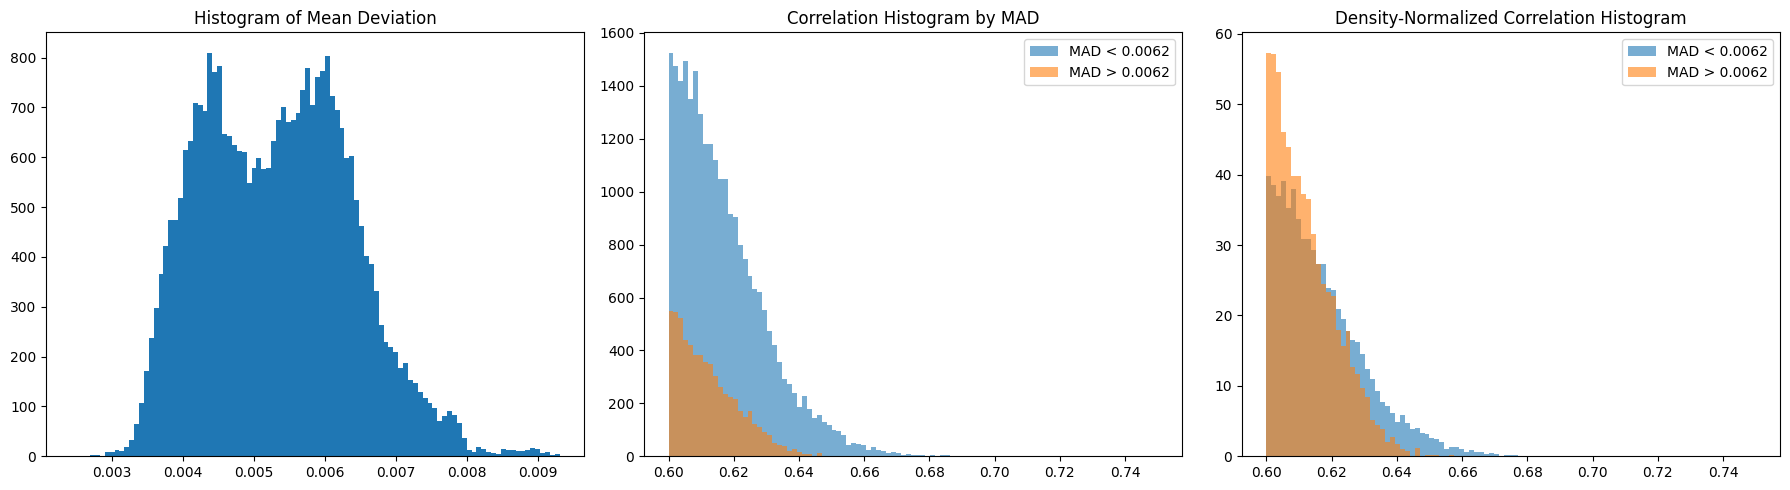

In [27]:
# my_df = gene_06.copy()
corr = my_df['correlation']
thresh = np.percentile(my_df['mean_deviation'], 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(my_df['mean_deviation'], bins=100)
axes[0].set_title('Histogram of Mean Deviation')

axes[1].hist(corr[my_df['mean_deviation'] < thresh], bins=np.linspace(0.6, 0.75, 100), alpha=0.6, label='MAD < '+str(round(thresh, 4)))
axes[1].hist(corr[my_df['mean_deviation'] > thresh], bins=np.linspace(0.6, 0.75, 100), alpha=0.6, label='MAD > '+str(round(thresh, 4)))
axes[1].legend()
axes[1].set_title('Correlation Histogram by MAD')

axes[2].hist(corr[my_df['mean_deviation'] < thresh], bins=np.linspace(0.6, 0.75, 100), alpha=0.6, label='MAD < '+str(round(thresh, 4)), density=True)
axes[2].hist(corr[my_df['mean_deviation'] > thresh], bins=np.linspace(0.6, 0.75, 100), alpha=0.6, label='MAD > '+str(round(thresh, 4)), density=True)
axes[2].legend()
axes[2].set_title('Density-Normalized Correlation Histogram')

plt.tight_layout()
plt.show()

In [54]:
# save significant gene pairs for rerunning on null models
filtered_df = my_df[my_df['mean_deviation'] < thresh]
print(filtered_df.shape)

for seed in filtered_df['seed'].unique():
    grouped = filtered_df[filtered_df['seed'] == seed].groupby('clearance gene')['risk gene'].apply(list)
    save_paired_genes_to_csv(grouped, f'../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_{int(seed)}.csv', chunk_size=10)

filtered_df = filtered_df.copy()
filtered_df.rename(columns={'t_90': 't_max'}, inplace=True)
out_df = filtered_df[['risk gene', 'clearance gene', 'seed', 't_max', 'correlation', 'mean_deviation']]
out_df.to_csv('../results/250829_r06_MAD80pct.csv', index=False)

(25273, 24)
Wrote 342 gene pairs in 47 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_42.csv
Wrote 553 gene pairs in 60 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_35.csv
Wrote 148 gene pairs in 19 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_27.csv
Wrote 74 gene pairs in 13 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_44.csv
Wrote 163 gene pairs in 26 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_38.csv
Wrote 5576 gene pairs in 585 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_31.csv
Wrote 2897 gene pairs in 318 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_32.csv
Wrote 2873 gene pairs in 298 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_33.csv
Wrote 3013 gene pairs in 320 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_49.csv
Wrote 40 gene pairs in 8 jobs to ../data/gene_labels/250829_pairs/GO_r06_MAD80pct_seed_26.csv
Wrote 1486 gene pairs i

In [53]:
# 1m30 A40 25k rows
spatial_df = dd.read_csv('../results/250902_spatial/*.csv')
spatial_df = spatial_df.set_index(spatial_df['clearance gene'] + ' ' + spatial_df['risk gene'])
spatial_df = spatial_df.drop(columns=['risk gene', 'clearance gene', 'seed'])
spatial_df = spatial_df.compute()

rewired_df = dd.read_csv('../results/250902_rewired/*.csv')
rewired_df = rewired_df.set_index(rewired_df['clearance gene'] + ' ' + rewired_df['risk gene'])
rewired_df = rewired_df.drop(columns=['risk gene', 'clearance gene', 'seed'])
rewired_df = rewired_df.compute()

gene_df = pd.read_csv('../results/250829_r06_MAD80pct.csv')
gene_df = gene_df.set_index(gene_df['clearance gene'] + ' ' + gene_df['risk gene'])

display(spatial_df.head())
display(gene_df.head())
print(spatial_df.shape)
print(rewired_df.shape)
print(gene_df.shape)

,p
ABCA2 AKT2,0.006786
ABCA2 ARIH2,0.005205
ABCA2 CACNG7,0.009083
ABCA2 CCNYL1,0.009508
ABCA2 CLN3,0.003085


,risk gene,clearance gene,seed,t_max,correlation,mean_deviation
PEX12 PPP4R2,PPP4R2,PEX12,42.0,7885.0,0.705562,0.005111
RNF144A FANCG,FANCG,RNF144A,35.0,1759.0,0.701547,0.004100
PEX12 RBMX2,RBMX2,PEX12,27.0,6004.0,0.698905,0.004012
PEX12 BCAR1,BCAR1,PEX12,27.0,7072.0,0.698177,0.004917
PEX12 SUV39H1,SUV39H1,PEX12,42.0,5875.0,0.697133,0.004135


(25273, 1)
(25151, 1)
(25273, 6)


In [ ]:
from statsmodels.stats.multitest import multipletests

my_df = gene_df.copy()

def fdr_bh(pvals, n_total):
    # Benjamini-Hochberg FDR correction
    n = len(pvals)
    sorted_indices = np.argsort(pvals)
    sorted_pvals = pvals[sorted_indices]
    fdr = np.empty(n)
    prev_fdr = 0
    for i in range(n-1, -1, -1):
        rank = i + 1
        fdr_val = sorted_pvals[i] * n_total / rank
        fdr_val = min(fdr_val, 1)
        fdr_val = min(fdr_val, prev_fdr) if i < n-1 else fdr_val
        fdr[i] = fdr_val
        prev_fdr = fdr_val
    fdr_corrected = np.empty(n)
    fdr_corrected[sorted_indices] = fdr
    return fdr_corrected

for null_type, null_df in zip(['rewired', 'spatial'], [rewired_df, spatial_df]):
    my_df = my_df.join(null_df, how='left', rsuffix='_' + null_type)
    my_df = my_df.rename(columns={'p': 'p_' + null_type})
    my_df['p_' + null_type + '_fdr'] = fdr_bh(my_df['p_' + null_type].values, 344*10297)
    # my_df['p_' + null_type + '_fdr'] = fdr_bh(my_df['p_' + null_type].values, len(my_df['p_' + null_type].values))
    # _, my_df['p_' + null_type + '_fdr'], _, _ = multipletests(my_df['p_' + null_type].values, method='fdr_bh')

display(my_df)


,risk gene,clearance gene,seed,t_max,correlation,mean_deviation,p_rewired,p_rewired_fdr,p_spatial,p_spatial_fdr
ABCA2 AKT2,AKT2,ABCA2,25.0,574.0,0.613942,0.004247,8.540723e-08,0.000048,0.006786,1.000000
ABCA2 ARIH2,ARIH2,ABCA2,25.0,589.0,0.602688,0.004567,4.940123e-07,0.000208,0.005205,0.974643
ABCA2 CACNG7,CACNG7,ABCA2,45.0,655.0,0.607848,0.005730,1.676767e-05,0.003966,0.009083,1.000000
ABCA2 CCNYL1,CCNYL1,ABCA2,16.0,556.0,0.600587,0.005258,8.027638e-05,0.015082,0.009508,1.000000
ABCA2 CLN3,CLN3,ABCA2,25.0,460.0,0.637123,0.004389,4.193029e-09,0.000004,0.003085,0.784619
...,...,...,...,...,...,...,...,...,...,...
ZFYVE26 TCAP,TCAP,ZFYVE26,49.0,1360.0,0.604756,0.005089,6.535709e-06,0.001789,0.004209,0.874811
ZFYVE26 TEKT2,TEKT2,ZFYVE26,49.0,1261.0,0.618685,0.005039,2.147769e-05,0.004890,0.003323,0.804879
ZFYVE26 TRMT5,TRMT5,ZFYVE26,31.0,610.0,0.605302,0.004750,1.071745e-06,0.000395,0.006153,1.000000
ZFYVE26 TTC8,TTC8,ZFYVE26,31.0,1846.0,0.605649,0.004155,1.008003e-05,0.002579,0.000037,0.202702


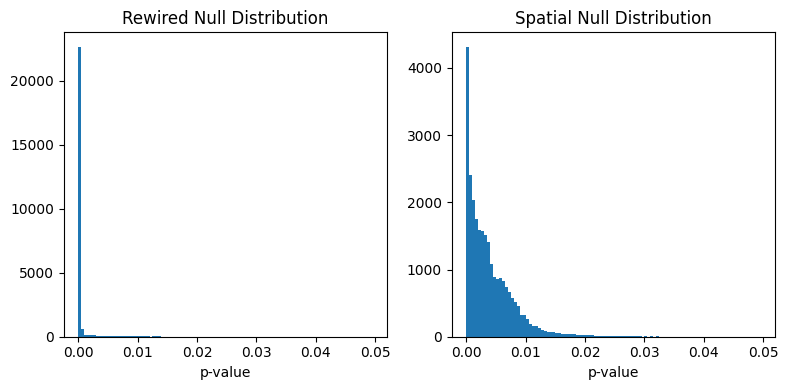

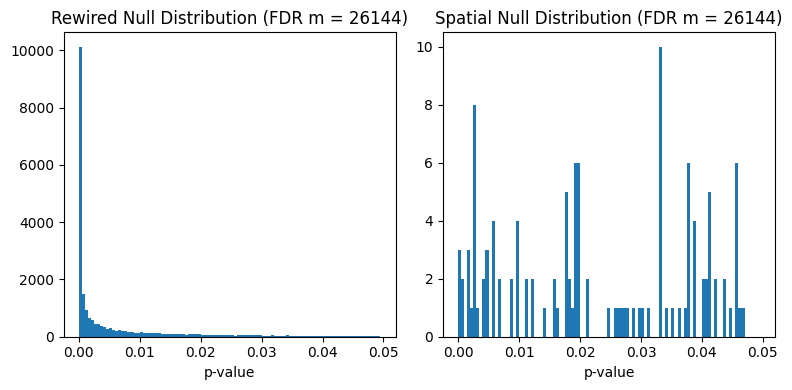

In [57]:
gene_df = my_df

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(gene_df['p_rewired'], bins=np.arange(0, 0.05, 0.0005))
plt.title('Rewired Null Distribution')
plt.xlabel('p-value')

plt.subplot(1, 2, 2)
plt.hist(gene_df['p_spatial'], bins=np.arange(0, 0.05, 0.0005))
plt.title('Spatial Null Distribution')
plt.xlabel('p-value')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
# plt.hist(gene_df['p_rewired_fdr'], bins=np.arange(0, 1, 0.01))
plt.hist(gene_df['p_rewired_fdr'], bins=np.arange(0, 0.05, 0.0005))
plt.title('Rewired Null Distribution (FDR m = 26144)')
plt.xlabel('p-value')

plt.subplot(1, 2, 2)
# plt.hist(gene_df['p_spatial_fdr'], bins=np.arange(0, 1, 0.01))
plt.hist(gene_df['p_spatial_fdr'], bins=np.arange(0, 0.05, 0.0005))
plt.title('Spatial Null Distribution (FDR m = 26144)')
plt.xlabel('p-value')

plt.tight_layout()
plt.show()

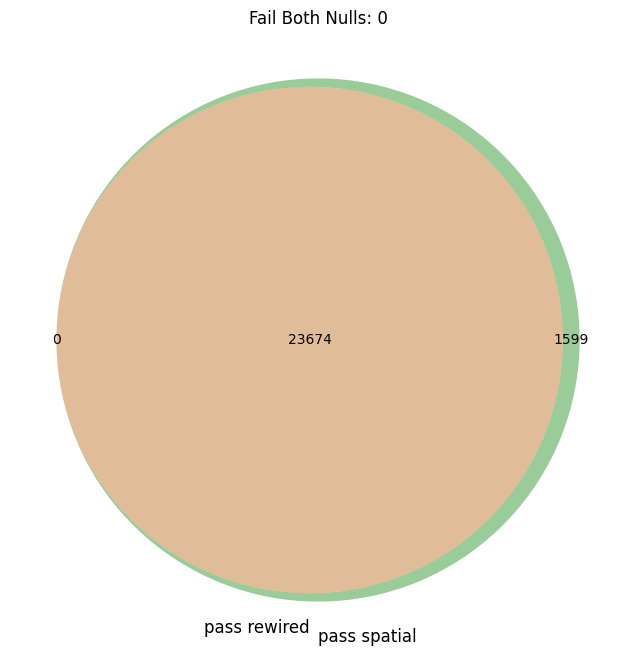

In [50]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt


# Define the sets
set_rewired = set(gene_df[gene_df['p_rewired_fdr'] < 0.05].index)
set_spatial = set(gene_df[gene_df['p_spatial_fdr'] < 0.05].index)
set_both = set_rewired & set_spatial
fail_both = ((gene_df['p_rewired_fdr'] > 0.05) & (gene_df['p_spatial_fdr'] > 0.05)).sum()

# Create the Venn diagram
plt.figure(figsize=(8, 8))
venn2([set_rewired, set_spatial], ('pass rewired', 'pass spatial'))

plt.title(f'Fail Both Nulls: {fail_both}')
plt.show()


In [64]:
display(filtered_df['clearance gene'].value_counts())
display(filtered_df['risk gene'].value_counts())

RNF144A    67
HLTF       19
VMP1        4
UBR2        1
Name: clearance gene, dtype: int64

AHNAK      1
SFRP2      1
RPS6KA4    1
RPS3       1
RPS17      1
          ..
CRYZL1     1
COQ4       1
CHAF1B     1
CC2D1A     1
NFS1       1
Name: risk gene, Length: 91, dtype: int64

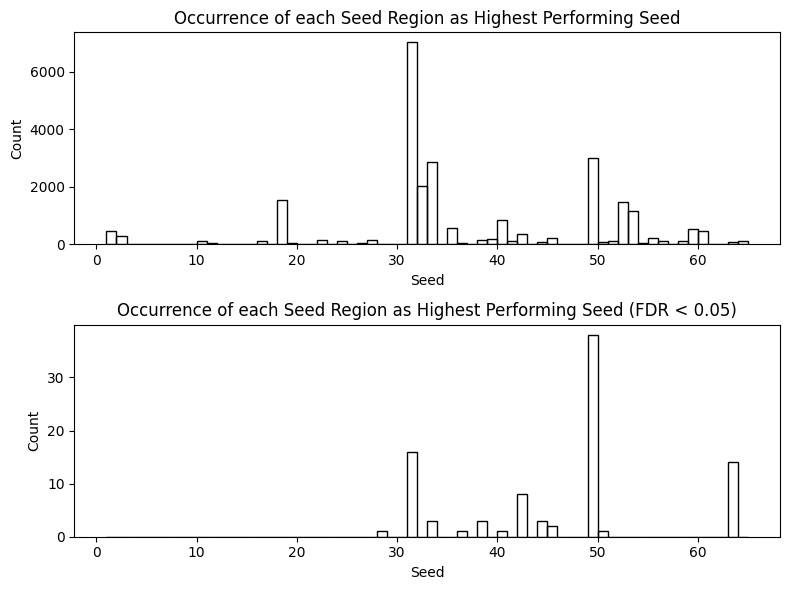

In [59]:
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
filtered_df = gene_df[(gene_df['p_rewired'] < 0.05) & (gene_df['p_spatial'] < 0.05)]
plt.hist(filtered_df['seed'], bins=range(1,66), edgecolor='black', fill=False)
# plt.hist(filtered_df['seed'], bins=filtered_df['seed'].nunique(), edgecolor='black', fill=False)
plt.xlabel('Seed')
plt.ylabel('Count')
plt.title('Occurrence of each Seed Region as Highest Performing Seed')

filtered_df = gene_df[(gene_df['p_rewired_fdr'] < 0.05) & (gene_df['p_spatial_fdr'] < 0.05)]
plt.subplot(2, 1, 2)
plt.hist(filtered_df['seed'], bins=range(1,66), edgecolor='black', fill=False)
# plt.hist(filtered_df['seed'], bins=filtered_df['seed'].nunique(), edgecolor='black', fill=False)
plt.xlabel('Seed')
plt.ylabel('Count')
plt.title('Occurrence of each Seed Region as Highest Performing Seed (FDR < 0.05)')

plt.tight_layout()
plt.show()

In [ ]:
# drop duplicate values from spatial null
a_spatial = dd.read_csv('../results/250521_spatial/*51.csv')
a_spatial = a_spatial.drop_duplicates()
a_spatial = a_spatial.set_index(a_spatial['clearance gene'] + ' ' + a_spatial['risk gene'])
p_spatial = dd.read_csv('../results/250521_spatial/*52.csv')
p_spatial = p_spatial.drop_duplicates()
p_spatial = p_spatial.set_index(p_spatial['clearance gene'] + ' ' + p_spatial['risk gene'])

a_spatial = a_spatial.compute()
p_spatial = p_spatial.compute()

a_rewired = dd.read_csv('../results/250521_rewired/*51.csv')
a_rewired = a_rewired.set_index(a_rewired['clearance gene'] + ' ' + a_rewired['risk gene'])
p_rewired = dd.read_csv('../results/250521_rewired/*52.csv')
p_rewired = p_rewired.set_index(p_rewired['clearance gene'] + ' ' + p_rewired['risk gene'])

a_rewired = a_rewired.compute()
p_rewired = p_rewired.compute()

In [ ]:
print(a_rewired.shape, p_rewired.shape)
a_rewired = a_rewired.drop_duplicates()
p_rewired = p_rewired.drop_duplicates()
print(a_rewired.shape, p_rewired.shape)

In [ ]:
display(a_spatial)

In [ ]:
# 4 min for 4M rows
from scipy.stats import norm

thresh = np.percentile(p_05['mean_deviation'], 90)
p_df = p_05[(p_05['mean_deviation'] < thresh) & (p_05['correlation'] > 0.5)][['correlation', 'mean_deviation']]
a_df = a_05[(a_05['mean_deviation'] < thresh) & (a_05['correlation'] > 0.5)][['correlation', 'mean_deviation']]

merge_dfs = []
# for seed_roi, rewired_null, spatial_null in zip([a_df, p_df], [a_rewired, a_spatial], [p_rewired, p_spatial]):
for null_df, null_type in zip([rewired_null, spatial_null], ['rewired', 'spatial']):
# for null_df, null_type in zip([p_spatial], ['spatial']):
    # Merge the null model dataframes with the original dataframe
    merge_df = seed_roi.merge(null_df, how='left', left_index=True, right_index=True, suffixes=('', '_' + null_type))
    # Calculate z-scores based on the summary statistics
    merge_df['z_' + null_type] = (merge_df['correlation'] - merge_df['mean']) / merge_df['SD']
    # Convert z-scores to p-values
    merge_df['p_' + null_type] = merge_df['z_' + null_type].apply(lambda z: 2 * (1 - norm.cdf(abs(z))))
    # display(merge_df)
    merge_dfs.append(merge_df)

merge_df = pd.concat(merge_dfs, axis=0, ignore_index=False)
# display(merge_dfs)

In [ ]:
p_df = p_05[(p_05['mean_deviation'] < thresh) & (p_05['correlation'] > 0.5)]
a_df = a_05[(a_05['mean_deviation'] < thresh) & (a_05['correlation'] > 0.5)]

gene_df = pd.concat([p_df.reset_index(drop=True), a_df.reset_index(drop=True)])
gene_df = gene_df.drop_duplicates(subset=['risk gene', 'clearance gene'])

print("Number of clearance genes: %d" % len(set(gene_df['clearance gene'])))
print("Number of risk genes: %d" % len(set(gene_df['risk gene'])))

grouped = gene_df.groupby('clearance gene')['risk gene'].apply(list)
save_paired_genes_to_csv(grouped, '../data/gene_labels/GO_gt_05_MAD.csv', chunk_size=1000)


In [ ]:
grouped = merge_df.groupby('clearance gene')['risk gene'].apply(list)
save_paired_genes_to_csv(grouped, '../data/gene_labels/GO_pass_spatial_gt_05.csv', chunk_size=10)
# merge_df[['clearance gene', 'risk gene', 'correlation', 'mean_deviation', 'p_spatial']].to_csv('../results/S132_corrs_p-vals.csv', index=False)


In [ ]:
pivot_df = gene_df.pivot_table(index=['genes'], columns='seed', values='correlation')
pivot_90 = gene_df.pivot_table(index=['genes'], columns='seed', values='t_90')
pivot_05 = gene_df.pivot_table(index=['genes'], columns='seed', values='t_05')

display(pivot_df.head())

In [ ]:
pivot_05 = gene_df[gene_df['correlation'] > 0.5].pivot_table(index=['genes'], columns='seed', values='correlation')

# Calculate standard deviation across columns (seeds) for each gene pair
seed_sd = pivot_05.std(axis=1)

plt.figure(figsize=(3, 6))
plt.boxplot(seed_sd.dropna().values, vert=True)
plt.title('Correlation Across Seeds, r > 0.5')
plt.ylabel('Standard Deviation')
plt.ylim(-0.01, 0.21)

# Overlay scatter plot of all std values (adds jitter for visibility)
x_jitter = np.random.normal(1, 0.04, size=len(seed_sd))
plt.scatter(x_jitter, seed_sd.values, alpha=0.005, s=2, color='tab:blue')
plt.show()

In [ ]:
gt_05 = gene_df[gene_df['correlation'] > 0.5]
threshold = pivot_df.quantile(0.99)
filtered_df = gt_05[gt_05.apply(lambda row: row['correlation'] > threshold[row['seed']], axis=1)]    # work on a subset of my_df (and a superset of threshold) or this operation will take very long
# gt_06[['clearance gene', 'risk gene']] = gt_06['genes'].str.split(' ', n=1, expand=True)
filtered_clr = filtered_df['clearance gene'].nunique()
filtered_risk = filtered_df['risk gene'].nunique()
print("Number of clearance genes above threshold: %d" % filtered_clr)
print("Number of risk genes above threshold: %d" % filtered_risk)

# Count the frequency of each clearance gene for each seed in gt_06
clearance_gene_seed_counts = filtered_df.groupby(['clearance gene', 'seed']).size().reset_index(name='count')
# For each clearance gene, count in how many unique seeds it appears
clearance_gene_seed_freq = clearance_gene_seed_counts.groupby('clearance gene')['seed'].nunique()

plt.figure(figsize=(8, 5))
plt.hist(clearance_gene_seed_freq, bins=range(1, clearance_gene_seed_freq.max()+2), align='left', edgecolor='black')
plt.xlabel('Number of Seeds')
plt.ylabel('Number of Clearance Genes')
plt.title('Frequency of Clearance Gene Appearance Across Seeds in 99th Percentile')
plt.tight_layout()
plt.show()

# For each risk gene, count in how many unique seeds it appears in gt_06
risk_gene_seed_counts = filtered_df.groupby(['risk gene', 'seed']).size().reset_index(name='count')
risk_gene_seed_freq = risk_gene_seed_counts.groupby('risk gene')['seed'].nunique()

plt.figure(figsize=(8, 5))
plt.hist(risk_gene_seed_freq, bins=range(1, risk_gene_seed_freq.max()+2), align='left', edgecolor='black')
plt.xlabel('Number of Seeds')
plt.ylabel('Number of Risk Genes')
plt.title('Frequency of Risk Gene Appearance Across Seeds in 99th Percentile')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the frequency of appearance for each gene pair across seeds
gene_seed_counts = filtered_df.groupby('genes')['seed'].nunique()
my_df_freq = filtered_df.copy()
my_df_freq['freq'] = my_df_freq['genes'].map(gene_seed_counts)
plot_df = my_df_freq[['seed', 'correlation', 'freq']]

# Normalize frequency for coloring
norm = plt.Normalize(plot_df['freq'].min(), plot_df['freq'].max())
cmap = plt.cm.viridis

plt.figure(figsize=(14, 6))
sc = plt.scatter(plot_df['seed'], plot_df['correlation'], c=plot_df['freq'], cmap=cmap, norm=norm, s=8, alpha=0.5)
plt.xlabel('Seed')
plt.ylabel('Correlation')
plt.title('Scatter Plot of Correlations by Seed, Colored by Frequency of Appearance')
cbar = plt.colorbar(sc, label='Frequency of Appearance Across Seeds')
plt.show()

In [ ]:
threshold = pivot_df.quantile(0.998)
filtered_df = pivot_df.apply(lambda col: col.where(col > threshold[col.name]))

plt.figure(figsize=(15, 5))
# plt.figure(figsize=(12, 6))
plt.boxplot(filtered_df.dropna().values)
plt.xticks(fontsize=8)
plt.xlabel('ROI')
plt.ylabel('Correlation')
plt.title('Boxplot of Correlations by Seed, 99.8th Percentile')
plt.show()


In [ ]:
# filtered_df = pivot_df.drop(columns=59)
# threshold = pivot_df.quantile(0.99)
# filtered_df = pivot_df[pivot_df > threshold]

plt.figure(figsize=(15, 5))
plt.xticks(fontsize=9)
plt.boxplot(pivot_df.dropna().values)
plt.xlabel('ROI')
plt.ylabel('Correlation')
plt.title('Boxplot of Correlations by Seed')
plt.show()

plt.figure(figsize=(15, 5))
plt.xticks(fontsize=9)
plt.boxplot(pivot_90.dropna().values)
plt.xlabel('ROI')
plt.ylabel('Correlation')
plt.title('Timesteps to 90% of Maximum Correlation by Seed')
plt.show()

plt.figure(figsize=(15, 5))
plt.xticks(fontsize=9)
plt.boxplot(pivot_05.dropna().values)
plt.xlabel('ROI')
plt.ylabel('Correlation')
plt.title('Timesteps to r > 0.5 by Seed')
plt.show()


In [ ]:
n_rows = 10
n_cols = 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12,10))
axes = axes.flatten()

# Precompute all seed_corrs as a list of Series
# seed_corrs = [gene_df[gene_df['seed'] == seed]['correlation'] for seed in range(1, 67)]
# med_corrs = [seed_corr.median() for seed_corr in seed_corrs]

for seed in range(1, 67):
    ax = axes[seed-1]
    ax.hist(seed_corrs[seed-1], bins=100, alpha=0.5, label=f'Seed {seed}')
    # ax.set_xlabel('Correlation')
    # ax.set_ylabel('Frequency')
    ax.set_title(f'seed #{seed}', fontsize=8)
    ax.set_xlim(-0.3, 0.6)
    ax.set_ylim(0, 150000)
    ax.tick_params(axis='both', labelsize=6)
    ax.axvline(med_corrs[seed-1], color='r', label=f'Med: {med_corrs[seed-1]:.2f}')
    # ax.legend()
for j in range(66, n_rows*n_cols):
    axes[j].axis('off')
    
plt.tight_layout()
plt.show()